In [1]:
#Core imports
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import chromedriver_binary  # auto-manages driver

from bs4 import BeautifulSoup
import time
import pandas as pd
import json
import re
import requests

# What these imports do -- So my future me won't get confused
'''
    selenium → opens browser like a human (needed, Myntra is JS-heavy)
    BeautifulSoup → parses HTML cleanly
    chromedriver_binary → avoids driver path headache (blessing)
    time → lets page load (because websites aren’t magic)
'''

'\n    selenium → opens browser like a human (needed, Myntra is JS-heavy)\n    BeautifulSoup → parses HTML cleanly\n    chromedriver_binary → avoids driver path headache (blessing)\n    time → lets page load (because websites aren’t magic)\n'

In [2]:
# Launch a Browser
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")
options.set_capability("goog:loggingPrefs", {"performance": "ALL"})

driver = webdriver.Chrome(options=options)
# No default URL loaded here!


In [3]:
# Load the product page from an easy-to-scrape platform
# Using a real, existing Amazon India product with reviews
product_url = "https://www.amazon.in/dp/B07DJCVTBH"  # Example: Mi Band 3 (has reviews)

driver.get(product_url)
time.sleep(5)  # let page load


In [4]:
# Open the reviews section (works for Amazon, Flipkart, etc.)
# Try to find and click "See all reviews" button
review_page_html = ""
review_window_handle = None

# Look for review section button/link
xpaths_to_try = [
    "//span[contains(text(), 'See all reviews')]/..",
    "//a[contains(text(), 'See all reviews')]",
    "//button[contains(., 'See all reviews')]",
    "//a[@data-hook='see-all-reviews']",
    "//span[@data-component-type='s-expandable-section']",
]

for xp in xpaths_to_try:
    try:
        elem = driver.find_element(By.XPATH, xp)
        if elem:
            driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", elem)
            time.sleep(1)
            driver.execute_script("arguments[0].click();", elem)
            time.sleep(3)
            break
    except:
        pass

time.sleep(2)


## **Main Thing - To Get HTML of the PAGE**

In [5]:
# Pull reviews directly from the page (scroll + collect)
review_texts_from_page = []
time.sleep(2)
last_count = 0
no_growth_rounds = 0
for scroll_attempt in range(100):
    # Try to collect visible review text blocks - works for Amazon, Flipkart, Myntra
    elems = driver.find_elements(By.CSS_SELECTOR, """
        div[data-hook="review-body-content"],
        span[data-hook="review-body"],
        div.a-expander-content,
        p.a-spacing-mini,
        div._27M-viRead-reviewTextContent,
        div.user-review-reviewTextWrapper
    """)
    texts = [e.text.strip() for e in elems if e.text and e.text.strip()]
    # Deduplicate while keeping order
    seen = set()
    deduped = []
    for t in texts:
        if t not in seen:
            seen.add(t)
            deduped.append(t)
    review_texts_from_page = deduped
    print(f"Scroll #{scroll_attempt+1}: Found {len(review_texts_from_page)} reviews")
    if len(review_texts_from_page) >= 200:  # Target 200+ reviews
        break
    if len(review_texts_from_page) == last_count:
        no_growth_rounds += 1
    else:
        no_growth_rounds = 0
        last_count = len(review_texts_from_page)
    # Scroll to load more
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(1.5)
    if no_growth_rounds >= 10:  # Stop if no growth for 10 rounds
        break

print(f"\n✓ Final: Collected {len(review_texts_from_page)} unique reviews")


Scroll #1: Found 9 reviews
Scroll #2: Found 9 reviews
Scroll #3: Found 9 reviews
Scroll #4: Found 9 reviews
Scroll #5: Found 9 reviews
Scroll #6: Found 9 reviews
Scroll #7: Found 9 reviews
Scroll #8: Found 9 reviews
Scroll #9: Found 9 reviews
Scroll #10: Found 9 reviews
Scroll #11: Found 9 reviews

✓ Final: Collected 9 unique reviews


In [6]:
html = driver.page_source

soup = BeautifulSoup(html, "html.parser")

print(soup.title.text)

OnePlus 6T McLaren Limited Edition (Speed Orange, 10GB RAM,256GB Storage) : Amazon.in: Electronics


In [7]:
# FInd Reviews

reviews = soup.find_all("div", class_="user-review-reviewTextWrapper")

for r in reviews[:5]:
    print(r.text.strip())
    print("-" * 50)

In [8]:
# Find more reviews by scrolling/clicking until target reached or no growth
# Multi-site selector support (Amazon, Flipkart, Myntra)
review_selector = """
div[data-hook="review-body-content"],
span[data-hook="review-body"],
div._27M-viRead-reviewTextContent,
div.user-review-reviewTextWrapper,
div._16PsC4,
div.t80lyc
"""
target_count = 200
max_rounds = 200
same_count_rounds = 0
last_count = 0

for round_num in range(max_rounds):
    reviews = driver.find_elements(By.CSS_SELECTOR, review_selector)
    count = len(reviews)
    if round_num % 10 == 0:
        print(f"Round {round_num+1}: {count} reviews found")

    if count >= target_count:
        print(f"✓ Target reached: {count} reviews")
        break

    if count == last_count:
        same_count_rounds += 1
    else:
        same_count_rounds = 0
        last_count = count

    # Try to click a load-more style button inside reviews
    try:
        load_more = driver.find_element(
            By.XPATH,
            "//button[contains(., 'Load More') or contains(., 'More Reviews') or contains(., 'Show More')] | //a[contains(., 'Load More') or contains(., 'More Reviews')]"
        )
        driver.execute_script("arguments[0].click();", load_more)
    except Exception:
        # Scroll the page
        scroll_container = driver.execute_script(
            """
            return Array.from(document.querySelectorAll('div'))
                .filter(el => /review/i.test(el.className) && el.scrollHeight > el.clientHeight)
                .sort((a, b) => b.scrollHeight - a.scrollHeight)[0] || null;
            """
        )
        if scroll_container:
            driver.execute_script("arguments[0].scrollTop = arguments[0].scrollHeight;", scroll_container)
        else:
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")

    try:
        WebDriverWait(driver, 5).until(
            lambda d: len(d.find_elements(By.CSS_SELECTOR, review_selector)) > count
        )
    except Exception:
        pass

    if same_count_rounds >= 10:
        print(f"⚠ No new reviews for 10 rounds. Final count: {count}")
        break


Round 1: 8 reviews found
Round 11: 8 reviews found
⚠ No new reviews for 10 rounds. Final count: 8


In [9]:
# Inspect network logs to find the exact reviews API URL
perf_logs = driver.get_log("performance")
print("Performance log entries:", len(perf_logs))

review_urls = []
for entry in perf_logs:
    try:
        msg = json.loads(entry["message"])
        message = msg.get("message", {})
        if message.get("method") != "Network.requestWillBeSent":
            continue
        req = message.get("params", {}).get("request", {})
        url = req.get("url", "")
        if "review" in url.lower():
            review_urls.append(url)
    except Exception:
        pass

# Deduplicate and show a few candidates
review_urls = list(dict.fromkeys(review_urls))
print("Network review URLs:")
for u in review_urls[:10]:
    print(" -", u)

Performance log entries: 3068
Network review URLs:
 - https://m.media-amazon.com/images/I/019vGlPeEzL.css?AUIClients/CustomerReviewsACRAssets
 - https://fls-eu.amazon.in/1/batch/1/OP/A21TJRUUN4KGV:525-7783135-0217369:JSE0WZ2EYQGSD71JVTXT$uedata=s:%2Frd%2Fuedata%3Fld%26v%3D0.342428.0%26id%3DJSE0WZ2EYQGSD71JVTXT%26sc0%3Daui%3Asw%3Appft%3Acallback_ricb%26bb0%3D130%26pc0%3D791%26ld0%3D791%26t0%3D1774943488423%26sc1%3DclickToCI%26bb1%3D407%26cf1%3D593%26pc1%3D699%26ld1%3D699%26t1%3D1774943488331%26sc2%3Dportal-bb%26pc2%3D0%26ld2%3D0%26t2%3D1774943488042%26sc3%3Dbuffet-high-priority-disclaimers-card_DetailPage_4%26bb3%3D538%26be3%3D538%26pc3%3D1751%26ld3%3D1751%26t3%3D1774943489383%26sc4%3DLocalServicesWidget%26pc4%3D540%26ld4%3D540%26t4%3D1774943488172%26sc5%3Dtell-amazon-desktop_DetailPage_6%26bb5%3D541%26be5%3D542%26pc5%3D726%26ld5%3D726%26t5%3D1774943488358%26sc6%3Daod-ingress-assets-load-time%26bb6%3D663%26pc6%3D663%26ld6%3D663%26t6%3D1774943488295%26sc7%3DSocialShareFramework.Latency.d

In [10]:
html = driver.page_source
soup = BeautifulSoup(html, "html.parser")

## **Extract Structured Data**

In [12]:
data = []

# Keep helpers available for later debug cells
def find_review_texts(payload):
    texts = []
    stack = [payload]
    while stack:
        current = stack.pop()
        if isinstance(current, dict):
            for _, v in current.items():
                if isinstance(v, (dict, list)):
                    stack.append(v)
            text = current.get("reviewText") or current.get("review") or current.get("comment")
            if isinstance(text, str) and text.strip():
                texts.append(text.strip())
        elif isinstance(current, list):
            for item in current:
                if isinstance(item, (dict, list)):
                    stack.append(item)
    return texts

def find_review_api_urls(page_text):
    normalized = page_text.replace("\\/", "/")
    patterns = [
        r"https://www\\.amazon\\.in/[^\"']*review[^\"']*",
        r"https://www\\.myntra\\.com/[^\"']*review[^\"']*",
        r"https://www\\.flipkart\\.com/[^\"']*review[^\"']*",
        r"/gateway/[^\"']*review[^\"']*",
    ]
    urls = []
    for p in patterns:
        urls.extend(re.findall(p, normalized))
    urls = [u if u.startswith("http") else f"https://www.amazon.in{u}" for u in urls]
    return list(dict.fromkeys(urls))

# Prefer scraped review list from scrolling cells
if "review_texts_from_page" in globals() and review_texts_from_page:
    for text in review_texts_from_page:
        data.append({"review": text})
else:
    # Fallback: extract review-like text blocks from current page HTML
    page_html = driver.page_source
    page_soup = BeautifulSoup(page_html, "html.parser")
    fallback_selectors = [
        'div[data-hook="review-body-content"]',
        'span[data-hook="review-body"]',
        'div.a-expander-content',
        'div._27M-viRead-reviewTextContent',
        'div.user-review-reviewTextWrapper',
    ]
    for sel in fallback_selectors:
        for el in page_soup.select(sel):
            txt = el.get_text(" ", strip=True)
            if txt:
                data.append({"review": txt})

# Build dataframe safely
df = pd.DataFrame(data)
if not df.empty:
    df = df.drop_duplicates(subset=["review"]).reset_index(drop=True)

print(f"Total extracted reviews: {len(df)}")
df.sample(min(12, len(df))) if len(df) > 0 else df


Total extracted reviews: 9


,review
5,I have always been a OnePlus fan and this mobi...
4,Overall: 8/10:\nA fantastic package at good va...
6,I gifted it to my dad...... Firstly he was a b...
8,Amazing phone!!! Can never go wrong with the o...
2,"That 10 gigs of RAM, holy moly,, ""SALUTE TO SP..."
1,I am writing this review on this very phone af...
7,The finger print scanner work 1 out of 5 times...
3,Overall: 8/10:\nA fantastic package at good va...
0,Best thing about this device has to be the Oxy...


In [ ]:
# Debug: show discovered review API URLs and sample response sizes

# Fallback-safe helper for this debug cell
def _find_review_api_urls_debug(text):
    normalized = text.replace("\\/", "/")
    patterns = [
        r"https://www\\.amazon\\.in/[^\"']*review[^\"']*",
        r"https://www\\.myntra\\.com/[^\"']*review[^\"']*",
        r"https://www\\.flipkart\\.com/[^\"']*review[^\"']*",
        r"/gateway/[^\"']*review[^\"']*",
    ]
    urls = []
    for p in patterns:
        urls.extend(re.findall(p, normalized))
    urls = [u if u.startswith("http") else f"https://www.amazon.in{u}" for u in urls]
    return list(dict.fromkeys(urls))

try:
    page_text = driver.page_source
except Exception as exc:
    print("Browser session is not active:", str(exc))
    print("Re-run cells 2, 3, and 4 to reopen browser and product page, then run this debug cell again.")
else:
    # Use global helper if available, otherwise local fallback
    discovered_urls = find_review_api_urls(page_text) if "find_review_api_urls" in globals() else _find_review_api_urls_debug(page_text)
    print("Discovered review URLs:")
    for u in discovered_urls[:10]:
        print(" -", u)

    print("\nNetwork review URLs seen by browser:")
    for u in review_urls[:10] if "review_urls" in globals() else []:
        print(" -", u)

    if not discovered_urls and ("review_urls" not in globals() or not review_urls):
        print("No review API URLs found. This usually means the page did not load review requests yet.")

InvalidSessionIdException: Message: invalid session id: session deleted as the browser has closed the connection
from disconnected: not connected to DevTools
  (Session info: chrome=146.0.7680.165); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#invalidsessionidexception
Stacktrace:
	chromedriver!GetHandleVerifier [0x7ff7b58629c5+2ed785]
	chromedriver!GetHandleVerifier [0x7ff7b558a0d0+14e90]
	chromedriver!(No symbol) [0x7ff7b52edb2d]
	chromedriver!(No symbol) [0x7ff7b52d8ca2]
	chromedriver!(No symbol) [0x7ff7b52ff416]
	chromedriver!(No symbol) [0x7ff7b53770e0]
	chromedriver!(No symbol) [0x7ff7b5393482]
	chromedriver!(No symbol) [0x7ff7b5339298]
	chromedriver!(No symbol) [0x7ff7b533a183]
	chromedriver!GetHandleVerifier [0x7ff7b588de0d+318bcd]
	chromedriver!GetHandleVerifier [0x7ff7b5888588+313348]
	chromedriver!GetHandleVerifier [0x7ff7b58a9d7a+334b3a]
	chromedriver!GetHandleVerifier [0x7ff7b55a6785+31545]
	chromedr

## **Sentiment Analysis by TextBlob**

In [ ]:
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download required NLTK data
try:
    nltk.data.find('vader_lexicon')
except LookupError:
    nltk.download('vader_lexicon')

# Initialize sentiment analyzers
vader = SentimentIntensityAnalyzer()

def get_sentiment_textblob(text):
    """TextBlob sentiment (good for general text)"""
    score = TextBlob(text).sentiment.polarity
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

def get_sentiment_vader(text):
    """VADER sentiment (better for social media/reviews)"""
    scores = vader.polarity_scores(text)
    compound = scores['compound']
    
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply both sentiment analyses
df["sentiment_textblob"] = df["review"].apply(get_sentiment_textblob)
df["sentiment_vader"] = df["review"].apply(get_sentiment_vader)

# Default to VADER (better for reviews)
df["sentiment"] = df["sentiment_vader"]

print("Sentiment Analysis Results:")
print(df[["review", "sentiment"]].head(15))
print("\n" + "="*80)
print("Sentiment Distribution:")
print(df["sentiment"].value_counts())


,review,sentiment
0,This cotton garment is not only extremely comf...,Positive
1,Nice pattern! It gives the perfect vibe for bo...,Positive
2,"Considering the price, the dress is good and q...",Positive
3,Great looking shirt under budget \nMust try th...,Positive
4,"Good quality shirt, must buy .",Positive
5,Brilliant purchased ever!!! The quality is som...,Positive
6,Really very nice product and quality also good...,Positive
7,The shirt feels really comfortable and fits pe...,Positive
8,The Invictus shirt offers a great blend of sty...,Positive
9,The shirt feels really comfortable and fits pe...,Positive


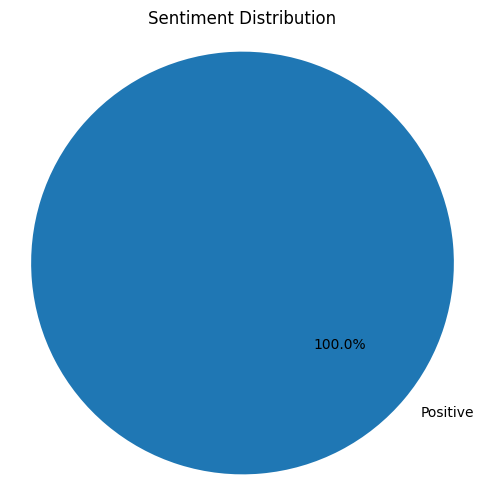

In [ ]:
import matplotlib.pyplot as plt

# Sentiment distribution
sentiment_counts = df['sentiment'].value_counts()

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'}
color_list = [colors.get(label, '#95a5a6') for label in sentiment_counts.index]
ax1.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=color_list)
ax1.set_title('Sentiment Distribution (VADER Analysis)', fontsize=14, fontweight='bold')

# Bar chart
sentiment_counts.plot(kind='bar', ax=ax2, color=color_list)
ax2.set_title('Sentiment Count', fontsize=14, fontweight='bold')
ax2.set_ylabel('Count')
ax2.set_xlabel('Sentiment')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Summary stats
print(f"\nTotal Reviews: {len(df)}")
print(f"Positive: {(sentiment_counts.get('Positive', 0) / len(df) * 100):.1f}%")
print(f"Negative: {(sentiment_counts.get('Negative', 0) / len(df) * 100):.1f}%")
print(f"Neutral: {(sentiment_counts.get('Neutral', 0) / len(df) * 100):.1f}%")


In [ ]:
# Save output safely
if "df" in globals() and len(df) > 0:
    df.to_csv("reviews.csv", index=False)
    print(f"Saved {len(df)} reviews to reviews.csv")
else:
    print("No reviews to save. Check scraping cells first.")